In [52]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

import matplotlib.pyplot as plt



1. Load dataset

In [53]:
data = pd.read_csv("credit_risk_pd_dataset.csv")

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

print("\nDefault rate by period:")
print(data.groupby("period")["default"].mean())

Dataset shape: (10000, 18)

First 5 rows:
  borrower_id       period   region employment_status        loan_purpose  \
0     B000001  Development  Alberta         Part-time  Debt consolidation   
1     B000002  Development  Ontario          Employed  Debt consolidation   
2     B000003          OOT  Ontario          Employed    Home improvement   
3     B000004  Development  Ontario          Employed           Education   
4     B000005  Development   Quebec     Self-employed            Personal   

  home_ownership  annual_income  loan_amount  debt_to_income  credit_score  \
0       Mortgage       41773.50     55325.12          0.3400         668.0   
1           Rent       85350.61     28260.96          0.2201         714.0   
2       Mortgage      194396.41     28153.86          0.3961         722.0   
3       Mortgage       76070.33     23497.05          0.3795         786.0   
4           Rent       90418.69     22724.37          0.6867         848.0   

   credit_utilization  pas

In [54]:
data.head()

,borrower_id,period,region,employment_status,loan_purpose,home_ownership,annual_income,loan_amount,debt_to_income,credit_score,credit_utilization,past_due_count,credit_inquiries,months_since_last_delinquency,employment_years,account_age_months,num_open_accounts,default
0,B000001,Development,Alberta,Part-time,Debt consolidation,Mortgage,41773.50,55325.12,0.3400,668.0,0.6888,2,3,60.8,10.2,80.4,6,0
1,B000002,Development,Ontario,Employed,Debt consolidation,Rent,85350.61,28260.96,0.2201,714.0,0.5380,1,1,46.9,31.4,35.1,14,0
2,B000003,OOT,Ontario,Employed,Home improvement,Mortgage,194396.41,28153.86,0.3961,722.0,0.4401,0,1,10.0,0.2,96.5,4,0
3,B000004,Development,Ontario,Employed,Education,Mortgage,76070.33,23497.05,0.3795,786.0,0.6140,0,0,9.1,6.5,33.0,8,0
4,B000005,Development,Quebec,Self-employed,Personal,Rent,90418.69,22724.37,0.6867,848.0,0.5767,1,0,36.8,1.5,29.5,7,0


2. Basic data checks

In [55]:
print("\nMissing values:")
print(data.isnull().sum())

print("\nTarget distribution:")
print(data["default"].value_counts(normalize=True))



Missing values:
borrower_id                        0
period                             0
region                             0
employment_status                  0
loan_purpose                       0
home_ownership                     0
annual_income                    100
loan_amount                        0
debt_to_income                     0
credit_score                     100
credit_utilization                 0
past_due_count                     0
credit_inquiries                   0
months_since_last_delinquency    100
employment_years                 100
account_age_months                 0
num_open_accounts                  0
default                            0
dtype: int64

Target distribution:
default
0    0.9649
1    0.0351
Name: proportion, dtype: float64


3. Feature engineering

In [56]:
data["loan_to_income"] = data["loan_amount"] / data["annual_income"]

data["high_dti_flag"] = (data["debt_to_income"] > 0.45).astype(int)

data["low_credit_score_flag"] = (data["credit_score"] < 620).astype(int)

data["high_utilization_flag"] = (data["credit_utilization"] > 0.70).astype(int)

data["recent_delinquency_flag"] = (
    data["months_since_last_delinquency"] < 12
).astype(int)

data["short_employment_flag"] = (
    data["employment_years"] < 2
).astype(int)


In [57]:
data.head()

,borrower_id,period,region,employment_status,loan_purpose,home_ownership,annual_income,loan_amount,debt_to_income,credit_score,...,employment_years,account_age_months,num_open_accounts,default,loan_to_income,high_dti_flag,low_credit_score_flag,high_utilization_flag,recent_delinquency_flag,short_employment_flag
0,B000001,Development,Alberta,Part-time,Debt consolidation,Mortgage,41773.50,55325.12,0.3400,668.0,...,10.2,80.4,6,0,1.324407,0,0,0,0,0
1,B000002,Development,Ontario,Employed,Debt consolidation,Rent,85350.61,28260.96,0.2201,714.0,...,31.4,35.1,14,0,0.331116,0,0,0,0,0
2,B000003,OOT,Ontario,Employed,Home improvement,Mortgage,194396.41,28153.86,0.3961,722.0,...,0.2,96.5,4,0,0.144827,0,0,0,1,1
3,B000004,Development,Ontario,Employed,Education,Mortgage,76070.33,23497.05,0.3795,786.0,...,6.5,33.0,8,0,0.308886,0,0,0,1,0
4,B000005,Development,Quebec,Self-employed,Personal,Rent,90418.69,22724.37,0.6867,848.0,...,1.5,29.5,7,0,0.251324,1,0,0,0,1


4. Split into development and OOT samples

In [58]:
development_data = data[data["period"] == "Development"].copy()
oot_data = data[data["period"] == "OOT"].copy()

drop_cols = ["borrower_id", "period", "default"]

X_dev = development_data.drop(columns=drop_cols)
y_dev = development_data["default"]

X_oot = oot_data.drop(columns=drop_cols)
y_oot = oot_data["default"]

5. Define numeric and categorical features

In [59]:
numeric_features = X_dev.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_dev.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)



Numeric features:
['annual_income', 'loan_amount', 'debt_to_income', 'credit_score', 'credit_utilization', 'past_due_count', 'credit_inquiries', 'months_since_last_delinquency', 'employment_years', 'account_age_months', 'num_open_accounts', 'loan_to_income', 'high_dti_flag', 'low_credit_score_flag', 'high_utilization_flag', 'recent_delinquency_flag', 'short_employment_flag']

Categorical features:
['region', 'employment_status', 'loan_purpose', 'home_ownership']


6. Preprocessing pipeline

In [60]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)


7. PD model using logistic regression

In [61]:
pd_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

pd_model.fit(X_dev, y_dev)

dev_predicted_pd = pd_model.predict_proba(X_dev)[:, 1]
oot_predicted_pd = pd_model.predict_proba(X_oot)[:, 1]

dev_predicted_default = (dev_predicted_pd >= 0.50).astype(int)
oot_predicted_default = (oot_predicted_pd >= 0.50).astype(int)


8. Model validation: AUC and KS

In [62]:
def calculate_auc_ks(y_true, predicted_pd):
    auc = roc_auc_score(y_true, predicted_pd)
    fpr, tpr, thresholds = roc_curve(y_true, predicted_pd)
    ks = max(tpr - fpr)
    return auc, ks


dev_auc, dev_ks = calculate_auc_ks(y_dev, dev_predicted_pd)
oot_auc, oot_ks = calculate_auc_ks(y_oot, oot_predicted_pd)

print("\n================ Model Validation Results ================")
print("Development AUC:", round(dev_auc, 4))
print("Development KS:", round(dev_ks, 4))
print("OOT AUC:", round(oot_auc, 4))
print("OOT KS:", round(oot_ks, 4))

print("\nOOT Confusion Matrix:")
print(confusion_matrix(y_oot, oot_predicted_default))

print("\nOOT Classification Report:")
print(classification_report(y_oot, oot_predicted_default))


================ Model Validation Results ================
Development AUC: 0.76
Development KS: 0.3894
OOT AUC: 0.7055
OOT KS: 0.3119

OOT Confusion Matrix:
[[2883    0]
 [ 115    0]]

OOT Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2883
           1       0.00      0.00      0.00       115

    accuracy                           0.96      2998
   macro avg       0.48      0.50      0.49      2998
weighted avg       0.92      0.96      0.94      2998



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


9. Portfolio segmentation

In [63]:
oot_results = X_oot.copy()
oot_results["actual_default"] = y_oot.values
oot_results["predicted_pd"] = oot_predicted_pd

oot_results["risk_segment"] = pd.qcut(
    oot_results["predicted_pd"],
    q=5,
    labels=[
        "Very Low Risk",
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Very High Risk"
    ]
)

segment_summary = oot_results.groupby("risk_segment", observed=False).agg(
    borrower_count=("predicted_pd", "count"),
    average_predicted_pd=("predicted_pd", "mean"),
    actual_default_rate=("actual_default", "mean")
).reset_index()

print("\n================ Portfolio Segmentation Summary ================")
print(segment_summary)


================ Portfolio Segmentation Summary ================
     risk_segment  borrower_count  average_predicted_pd  actual_default_rate
0   Very Low Risk             600              0.006134             0.006667
1        Low Risk             599              0.013719             0.026711
2     Medium Risk             600              0.022947             0.033333
3       High Risk             599              0.038397             0.036728
4  Very High Risk             600              0.094393             0.088333


10. Backtesting / calibration check

In [64]:
backtesting_results = segment_summary.copy()

backtesting_results["calibration_difference"] = (
    backtesting_results["actual_default_rate"]
    - backtesting_results["average_predicted_pd"]
)

backtesting_results["absolute_difference"] = (
    backtesting_results["calibration_difference"].abs()
)

print("\n================ Backtesting / Calibration Results ================")
print(backtesting_results)




================ Backtesting / Calibration Results ================
     risk_segment  borrower_count  average_predicted_pd  actual_default_rate  \
0   Very Low Risk             600              0.006134             0.006667   
1        Low Risk             599              0.013719             0.026711   
2     Medium Risk             600              0.022947             0.033333   
3       High Risk             599              0.038397             0.036728   
4  Very High Risk             600              0.094393             0.088333   

   calibration_difference  absolute_difference  
0                0.000533             0.000533  
1                0.012992             0.012992  
2                0.010386             0.010386  
3               -0.001669             0.001669  
4               -0.006059             0.006059  


11. Risk ranking validation

In [65]:
print("\n================ Risk Ranking Check ================")

for i in range(len(segment_summary) - 1):
    current_segment = segment_summary.loc[i, "risk_segment"]
    next_segment = segment_summary.loc[i + 1, "risk_segment"]

    current_default_rate = segment_summary.loc[i, "actual_default_rate"]
    next_default_rate = segment_summary.loc[i + 1, "actual_default_rate"]

    print(
        f"{current_segment} to {next_segment}: "
        f"{round(current_default_rate, 4)} -> {round(next_default_rate, 4)}"
    )

print(
    "\nInterpretation: A strong PD model should generally show increasing "
    "actual default rates from lower-risk to higher-risk segments."
)



================ Risk Ranking Check ================
Very Low Risk to Low Risk: 0.0067 -> 0.0267
Low Risk to Medium Risk: 0.0267 -> 0.0333
Medium Risk to High Risk: 0.0333 -> 0.0367
High Risk to Very High Risk: 0.0367 -> 0.0883

Interpretation: A strong PD model should generally show increasing actual default rates from lower-risk to higher-risk segments.


12. PSI monitoring

In [66]:
def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    psi = np.sum(psi_values)

    return psi

In [67]:
psi_score = calculate_psi(dev_predicted_pd, oot_predicted_pd)

print("\n================ PSI Monitoring Result ================")
print("PSI Score:", round(psi_score, 4))

if psi_score < 0.10:
    psi_interpretation = "No significant population shift."
elif psi_score < 0.25:
    psi_interpretation = "Moderate population shift. Monitoring is recommended."
else:
    psi_interpretation = "Significant population shift. Model review may be required."

print("PSI Interpretation:", psi_interpretation)


================ PSI Monitoring Result ================
PSI Score: 0.0037
PSI Interpretation: No significant population shift.


13. Logistic regression coefficient interpretation

In [68]:
preprocessor_fitted = pd_model.named_steps["preprocessor"]
logistic_model = pd_model.named_steps["logistic_regression"]

numeric_feature_names = numeric_features

categorical_feature_names = (
    preprocessor_fitted
    .named_transformers_["categorical"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

all_feature_names = numeric_feature_names + categorical_feature_names

coefficients = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": logistic_model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

print("\n================ Logistic Regression Coefficients ================")
print(coefficients.head(15))


================ Logistic Regression Coefficients ================
                            feature  coefficient
25     employment_status_Unemployed     0.558159
4                credit_utilization     0.410623
5                    past_due_count     0.311756
1                       loan_amount     0.308373
2                    debt_to_income     0.303223
27  loan_purpose_Debt consolidation     0.264930
34              home_ownership_Rent     0.259696
6                  credit_inquiries     0.252722
17                   region_Alberta     0.248872
32             home_ownership_Other     0.157784
21                    region_Quebec     0.121806
20                     region_Other     0.102941
12                    high_dti_flag     0.080779
13            low_credit_score_flag     0.054609
28           loan_purpose_Education     0.047154


14. Credit risk interpretation

In [69]:
print("\n================ Credit Risk Interpretation ================")

print("- The model estimates borrower-level probability of default using logistic regression.")
print("- Financial variables include income, loan amount, DTI, credit score, and utilization.")
print("- Behavioral variables include past-due count, credit inquiries, delinquency history, and account age.")
print("- Feature engineering created risk flags and loan-to-income ratio.")
print("- Portfolio segmentation groups borrowers into risk bands based on predicted PD.")
print("- AUC measures the model's ability to distinguish default borrowers from non-default borrowers.")
print("- KS statistic measures separation between default and non-default borrower distributions.")
print("- Backtesting compares predicted PD with actual default rates by risk segment.")
print("- OOT validation checks model performance on an unseen population.")
print("- PSI monitors whether the borrower population shifted between development and OOT samples.")



================ Credit Risk Interpretation ================
- The model estimates borrower-level probability of default using logistic regression.
- Financial variables include income, loan amount, DTI, credit score, and utilization.
- Behavioral variables include past-due count, credit inquiries, delinquency history, and account age.
- Feature engineering created risk flags and loan-to-income ratio.
- Portfolio segmentation groups borrowers into risk bands based on predicted PD.
- AUC measures the model's ability to distinguish default borrowers from non-default borrowers.
- KS statistic measures separation between default and non-default borrower distributions.
- Backtesting compares predicted PD with actual default rates by risk segment.
- OOT validation checks model performance on an unseen population.
- PSI monitors whether the borrower population shifted between development and OOT samples.


15. Curve Visualization

ROC Curve

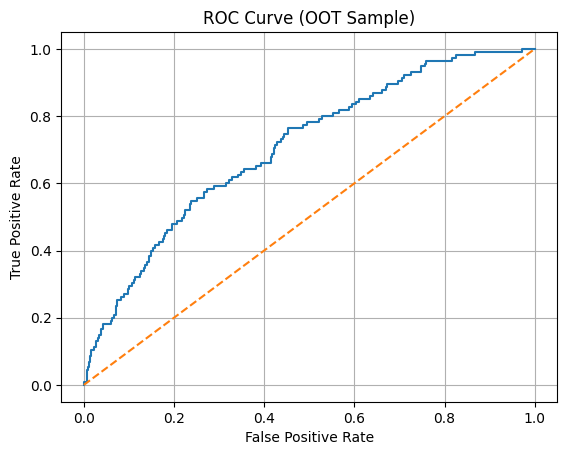

In [70]:
# ============================================================
# ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_oot, oot_predicted_pd)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve (OOT Sample)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid()
plt.show()

KS Curve

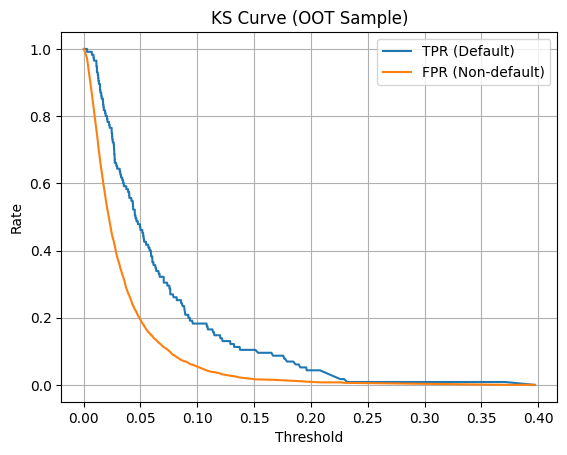

In [71]:
# ============================================================
# KS Curve
# ============================================================


plt.figure()

plt.plot(thresholds, tpr, label="TPR (Default)")
plt.plot(thresholds, fpr, label="FPR (Non-default)")

plt.title("KS Curve (OOT Sample)")
plt.xlabel("Threshold")
plt.ylabel("Rate")

plt.legend()
plt.grid()

plt.show()

Segmentation Chart

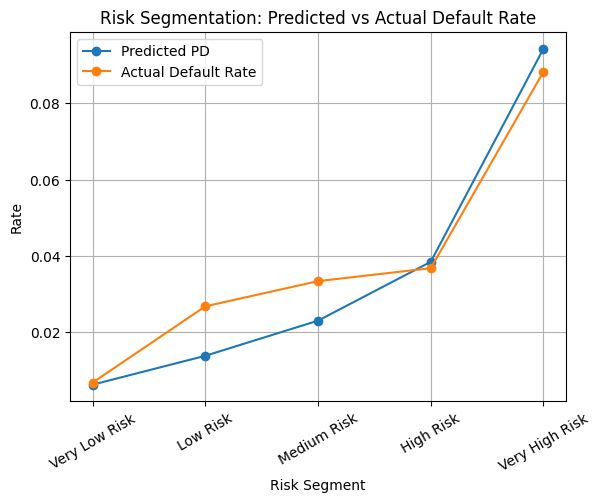

In [72]:
# ============================================================
# Risk Segmentation Chart
# ============================================================

plt.figure()

x = segment_summary["risk_segment"]

plt.plot(x, segment_summary["average_predicted_pd"], marker='o', label="Predicted PD")
plt.plot(x, segment_summary["actual_default_rate"], marker='o', label="Actual Default Rate")

plt.title("Risk Segmentation: Predicted vs Actual Default Rate")
plt.xlabel("Risk Segment")
plt.ylabel("Rate")

plt.legend()
plt.grid()

plt.xticks(rotation=30)

plt.show()

PSI Visualization

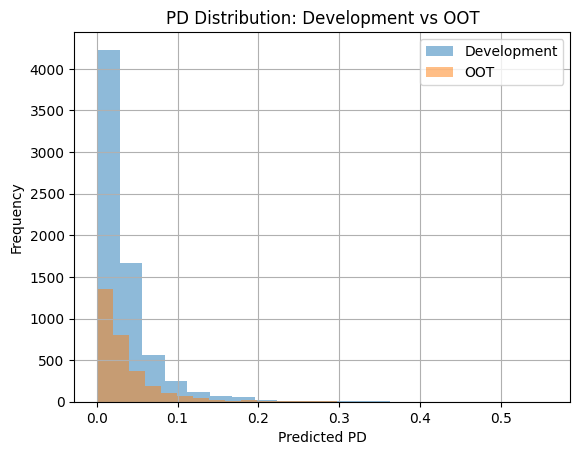

In [73]:
# ============================================================
# PSI Distribution Plot
# ============================================================

plt.figure()

plt.hist(dev_predicted_pd, bins=20, alpha=0.5, label="Development")
plt.hist(oot_predicted_pd, bins=20, alpha=0.5, label="OOT")

plt.title("PD Distribution: Development vs OOT")
plt.xlabel("Predicted PD")
plt.ylabel("Frequency")

plt.legend()
plt.grid()

plt.show()

16. Export project outputs

In [74]:
performance_summary = pd.DataFrame({
    "Sample": ["Development", "OOT"],
    "AUC": [dev_auc, oot_auc],
    "KS Statistic": [dev_ks, oot_ks]
})

psi_summary = pd.DataFrame({
    "Metric": ["PSI"],
    "Value": [psi_score],
    "Interpretation": [psi_interpretation]
})

performance_summary.to_csv("model_performance_summary.csv", index=False)
segment_summary.to_csv("portfolio_segmentation_summary.csv", index=False)
backtesting_results.to_csv("backtesting_calibration_results.csv", index=False)
coefficients.to_csv("logistic_regression_coefficients.csv", index=False)
psi_summary.to_csv("psi_monitoring_summary.csv", index=False)
oot_results.to_csv("borrower_level_oot_pd_results.csv", index=False)

print("\nOutput files exported successfully.")


Output files exported successfully.
